In [5]:
import requests
import numpy as np
import pandas as pd
from datetime import datetime
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [6]:
my_key='722729cfa99e33f0f76a6c4385beb4a6394f1728'


## US Census: Finding variable code (ie B01003_001E for total population)
When you’re trying to web-scrape a Census variable, the safest way is to check the official variables.json metadata file (for example: https://api.census.gov/data/2024/acs/acs1/subject/variables.json) and search for keywords to find the exact variable code.    
It’s also totally fine to start from the Census website table itself: just look at the table name, identify which row and column your data lives in, and then map that position to the corresponding variable code.

## Function to fetch multiple variables from United States Census Bureau

In [8]:
def fetch_msa_variable_acs1_recent_n_years(var_code: list, var_name: list, api_key: str, n_years: int, max_lookback: int = 10):
    """
    Fetch one ACS1 variable for all MSAs for the most recent n available years.
    Census null sentinel values (-666666666, -999999999, -888888888) are replaced with NaN.
    """
    CENSUS_NULL_SENTINELS = {-666666666, -999999999, -888888888}

    current_year = datetime.today().year
    dfs = []
    collected = 0

    for year in range(current_year, current_year - max_lookback, -1):

        if collected >= n_years:
            break

        if var_code.startswith("S"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1/subject"
        elif var_code.startswith("B"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1"
        elif var_code.startswith("D"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1/profile"
        else:
            raise ValueError("Unsupported variable code prefix")

        params = {
            "get": f"NAME,{var_code}",
            "for": "metropolitan statistical area/micropolitan statistical area:*",
            "key": api_key
        }

        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            continue

        data = response.json()
        if len(data) <= 1:
            continue

        df = pd.DataFrame(data[1:], columns=data[0])
        if var_code not in df.columns:
            continue

        df = df.rename(columns={
            var_code: var_name,
            "NAME": "msa_name",
            "metropolitan statistical area/micropolitan statistical area": "msa_code"
        })

        df[var_name] = pd.to_numeric(df[var_name], errors="coerce")
        # ── BUG FIX: Replace Census null sentinel values with NaN ──
        df[var_name] = df[var_name].replace(CENSUS_NULL_SENTINELS, np.nan)
        df["year"] = year

        dfs.append(df[["msa_code", "msa_name", "year", var_name]])
        collected += 1

    if not dfs:
        raise RuntimeError("No available data found")

    return pd.concat(dfs, ignore_index=True)


In [9]:
# collect useful variables their codes to this dictionary.
variables_acs1 = {"Total_Population": "B01003_001E",
                  "Laborforce_Population": "DP03_0002E",
                  "Employed": "DP03_0004E",
                  "Median_Household_Income": "S1903_C03_001E",
                  "Median_House_Value": "B25077_001E",
                  "Total_Housing_Units": "B25002_001E",
                  "House_Occupied": "B25002_002E",
                  "House_Vacant": "B25002_003E",
                  "Median_Gross_Rent": "B25064_001E",
                  "5_to_9_units": "DP04_0011E",
                  "10_to_19_units":"DP04_0012E",
                  "20_or_more_units":"DP04_0013E"
                 }

In [10]:
# Model instantiation: Fetch ACS1 variables for all MSAs for the most recent n+1 available years.
# n+1 years of data is needed to construct growh factors, i.e. population growth
dfs = []
for var_name, var_code in variables_acs1.items():
  df = fetch_msa_variable_acs1_recent_n_years(var_code = var_code, var_name = var_name, api_key = my_key, n_years = 5+1)
  dfs.append(df)

In [11]:
msa_features_recent_5_years = reduce(lambda left, right: pd.merge(
        left, right, on=["msa_code", "msa_name", "year"], how="outer"), dfs)
msa_features_recent_5_years = msa_features_recent_5_years.sort_values(by=['msa_code', 'year'])

msa_features_recent_5_years['Total_Multi_Units']=msa_features_recent_5_years['5_to_9_units']\
+msa_features_recent_5_years['10_to_19_units']+msa_features_recent_5_years['20_or_more_units']

# Filter out MSAs with a total population over 300,000 by the most recent year
population_requirement=300000

most_recent_year = msa_features_recent_5_years['year'].max()
eligible_msa = msa_features_recent_5_years.loc[
    (msa_features_recent_5_years['year'] == most_recent_year) &
    (msa_features_recent_5_years['Total_Population'] >= population_requirement) &
    (msa_features_recent_5_years['msa_name'].str.endswith('Metro Area')),
    'msa_code'].unique()

msa_features_recent_5_years = msa_features_recent_5_years[
    msa_features_recent_5_years['msa_code'].isin(eligible_msa)]

# Print out the number of MSAs achieving population requirement
print(f"By the year {most_recent_year}, {msa_features_recent_5_years['msa_code'].nunique()} \
MSAs have a population of over {population_requirement}.")

By the year 2024, 173 MSAs have a population of over 300000.


In [12]:
# Note that the U.S. Census Bureau did not release standard 2020 American Community Survey (ACS) 1-year estimates
# because the COVID-19 pandemic severely disrupted data collection, leading to low response rates and high nonresponse bias.
# If it is extremely necessary to use consecutive data including 2020, we shall switch from acs1 to acs5.
msa_features_recent_5_years[msa_features_recent_5_years['msa_code']=='16980']

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,House_Vacant,Median_Gross_Rent,5_to_9_units,10_to_19_units,20_or_more_units,Total_Multi_Units
512,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2018,9497790,5089589,4792415,70760,247800,3858653,3538101,320552,1110,294938.0,168767.0,512310.0,976015.0
513,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2019,9457867,5059338,4796817,75379,253800,3869464,3539174,330290,1139,285616.0,168737.0,538489.0,992842.0
514,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2021,9510390,5063933,4663627,78166,281100,3956161,3670416,285745,1225,282262.0,176507.0,556612.0,1015381.0
515,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2022,9442159,5097936,4833113,82914,301300,3968906,3726266,242640,1294,304321.0,180421.0,572979.0,1057721.0
510,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2023,9262559,5053959,4791844,87071,316500,3911902,3671659,240243,1390,291526.0,181012.0,565152.0,1037690.0
511,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2024,9406924,5137844,4840603,90770,339700,3924020,3690402,233618,1469,282946.0,186917.0,588696.0,1058559.0


## Joining US Census data with tax data (Updated)
While US census data are collected on MSA scale, tax data are collected on different scales, using **Gemini**:    
- Residential Effective Rate: State Averaged
- Commercial Effective Rate: proxy of the Largest City of that State

To merge the two datasets in a consistent manner, we assign each MSA the state code corresponding to the state in which its largest principal city (the 1st city in MSA title) is located. We then use this state code to merge the MSA-level Census data with the state-level tax data.

Example:    
(1) **MSA = 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD Metro Area'**   
----> State Code = 'PA'     
----> Principle city of the state = 'Philadelphia'  
----> MSA US Census data Joined by *Pennsylvania Average Residential Effective Tax Rate* and *Philadelphia Commercial Effective Tax Rate*

(2) **MSA = 'Akron, OH Metro Area'**   
----> State Code = 'OH'   
----> Principle city of the state = 'Columbus'   
----> MSA US Census data Joined by *Ohio Average Residential Effective Tax Rate* and *Columbus Commercial Effective Tax Rate*

In [ ]:
# colab workflow for file upload. Uncomment the following lines if you are running this notebook in Google Colab and want to upload a local file.
# from google.colab import files
# uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
file_name = "State Property Tax Comparison_ Hotels vs. Multifamily_New.xlsx"
df_tax = pd.read_excel(file_name, sheet_name='Tax new')
df_tax['Diff_Effective_Rate']=df_tax['Hotel Effective Rate']-df_tax['Multifamily Effective Rate']
df_tax.head(10)

,State Code,State,MSA (Core County),Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate
0,AZ,Arizona,Maricopa,0.014450,0.009320,0.00513
1,AL,Alabama,Birmingham,0.014500,0.007250,0.00725
2,AK,Alaska,Anchorage,0.016145,0.016145,0.00000
3,AR,Arkansas,Little Rock,0.014040,0.014040,0.00000
4,CA,California,Los Angeles,0.012500,0.012500,0.00000
5,CO,Colorado,Denver,0.019900,0.005540,0.01436
6,CT,Connecticut,Hartford,0.048300,0.048300,0.00000
7,DE,Delaware,New Castle,0.020300,0.020300,0.00000
8,FL,Florida,Miami-Dade,0.019988,0.019988,0.00000
9,GA,Georgia,Fulton,0.016532,0.016532,0.00000


In [ ]:
# extracting the state code where the largest principal city of the MSA is located
def extract_principal_state(msa_name):
    match =  msa_name.split(', ')[1].split(' ')[0].split('-')[0]
    return match
# extracting the largest principal city of each MSA
def extract_principal_city(msa_name):
    return msa_name.split(',')[0].split('-')[0]

msa_features_recent_5_years['State Code']=msa_features_recent_5_years['msa_name'].apply(extract_principal_state)
msa_features_recent_5_years['Principal_City']=msa_features_recent_5_years['msa_name'].apply(extract_principal_city)

# merging two datasets
msa_features_recent_5_years=pd.merge(msa_features_recent_5_years,
        df_tax[['State', 'State Code', 'Hotel Effective Rate',
       'Multifamily Effective Rate',
       'Diff_Effective_Rate']], on='State Code', how='left')

msa_features_recent_5_years=msa_features_recent_5_years.dropna() # only 1 Puerto Rican MSA is deleted

msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,5_to_9_units,10_to_19_units,20_or_more_units,Total_Multi_Units,State Code,Principal_City,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,12975,13435,21032,47442,OH,Akron,Ohio,0.0406,0.0406,0.0
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,16498,12021,21692,50211,OH,Akron,Ohio,0.0406,0.0406,0.0
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,14485,10987,19882,45354,OH,Akron,Ohio,0.0406,0.0406,0.0
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,13528,11199,23140,47867,OH,Akron,Ohio,0.0406,0.0406,0.0
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,11945,12604,22320,46869,OH,Akron,Ohio,0.0406,0.0406,0.0


## Joining Cap Rate data (data collected using Gemini)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Cap_Rate_Gemini.xlsx to Cap_Rate_Gemini.xlsx


In [ ]:
cap_file = "Cap Rate Arbitrage Model Update.xlsx"
OPEX_file = "State OPEX Assumptions for Housing.xlsx"
df_cap = pd.read_excel(cap_file)
df_OER = pd.read_excel(OPEX_file)
df_cap['Cap Spread'] = df_cap['Hotel Cap Rate'] - df_cap['Apt Cap Rate']
df_OER = df_OER.rename(columns={'Default OPEX %':'OPEX%'})
df_cap.head()

,State Code,State,Largest MSA,Hotel Cap,Multifamily Cap,Cap Spread,Unnamed: 6,Unnamed: 7
0,AZ,Arizona,Phoenix,0.0825,0.055,0.0275,NaN,NaN
1,AL,Alabama,Birmingham,0.0875,0.070,0.0175,NaN,NaN
2,AR,Arkansas,Little Rock,0.0900,0.065,0.0250,NaN,NaN
3,CA,California,Los Angeles,0.0750,0.051,0.0240,NaN,NaN
4,CO,Colorado,Denver,0.0800,0.053,0.0270,NaN,NaN


In [ ]:
msa_features_recent_5_years=pd.merge(msa_features_recent_5_years,
        df_cap[['State Code', 'Hotel Cap Rate', 'Apt Cap Rate', 'Cap Spread']], on='State Code', how='left')

msa_features_recent_5_years=pd.merge(msa_features_recent_5_years,
        df_OER[['State Code', 'OPEX%']], on='State Code', how='left')
msa_features_recent_5_years=msa_features_recent_5_years.dropna()
msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,State Code,Principal_City,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate,Hotel Cap,Multifamily Cap,Cap Spread,OER
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,0.431
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,0.431
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,0.431
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,0.431
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,0.431


In [ ]:
df_2024 = msa_features_recent_5_years[msa_features_recent_5_years['year']==2024]

df_2024=df_2024[['msa_code','msa_name', 'OPEX%']].sort_values('OPEX%', ascending = False)
df_2024.head(50)


,msa_code,msa_name,OER
390,26580,"Huntington-Ashland, WV-KY-OH Metro Area",0.458
542,33100,"Miami-Fort Lauderdale-West Palm Beach, FL Metr...",0.458
452,29180,"Lafayette, LA Metro Area",0.462
650,36740,"Orlando-Kissimmee-Sanford, FL Metro Area",0.463
872,43780,"South Bend-Mishawaka, IN-MI Metro Area",0.463
662,37340,"Palm Bay-Melbourne-Titusville, FL Metro Area",0.467
354,25060,"Gulfport-Biloxi, MS Metro Area",0.467
53,12100,"Atlantic City-Hammonton, NJ Metro Area",0.467
758,40220,"Roanoke, VA Metro Area",0.468
1000,49620,"York-Hanover, PA Metro Area",0.468


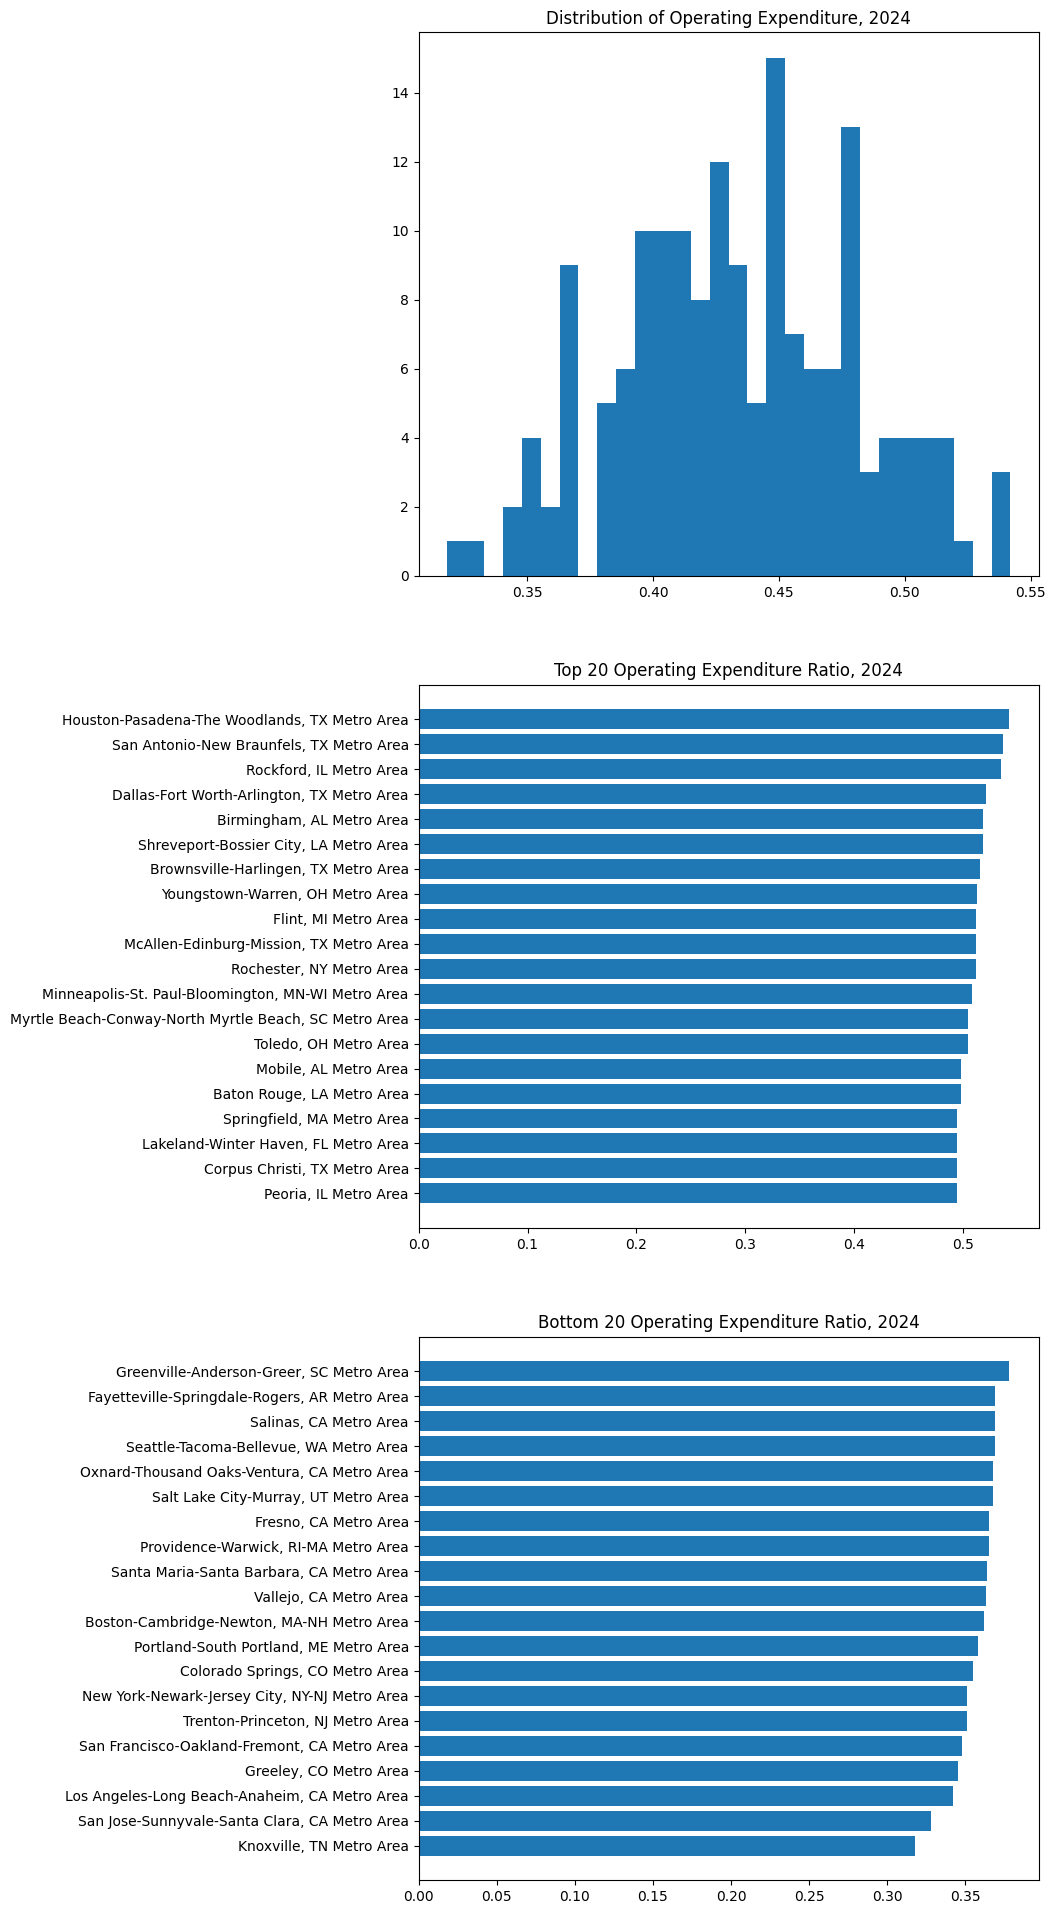

In [ ]:
fig=plt.figure(figsize=(8,24))

ax1=fig.add_subplot(3,1,1)
ax1.hist(df_2024['OPEX%'], bins=30)
ax1.set_title("Distribution of Operating Expenditure Ratio, 2024")

ax2=fig.add_subplot(3,1,2)
ax2.barh(df_2024['msa_name'][-20:], df_2024['OPEX%'][-20:])
ax2.set_title("Top 20 Operating Expenditure Ratio, 2024")

ax3=fig.add_subplot(3,1,3)
ax3.barh(df_2024['msa_name'][:20], df_2024['OPEX%'][:20])
ax3.set_title("Bottom 20 Operating Expenditure Ratio, 2024")



plt.show()

## Joining ESG data (past 5 available years: 2019; 2021-2024)
Data source: RESNET (Residential Energy Services Network)  

Only PDF available. Need to manually convert PDF into Excel    
(free PDF conversion tool: https://www.ilovepdf.com/)


HERS Index: The Home Energy Rating System (HERS) Index is the industry standard by which a home’s energy efficiency is measured. It’s also the nationally recognized system for inspecting and calculating a home’s energy performance.
https://www.hersindex.com/hers-index/understanding-hers-index/

A certified RESNET Home Energy Rater assesses the energy efficiency of a home, assigning it a relative performance score (the HERS® Index Score). **The lower the number, the more energy efficient the home.** A home built to 2006 energy efficiency standards scores 100.

A home with a HERS® Index Score of 70 is 30% more energy efficient than the RESNET Reference Home.
A home with a HERS® Index Score of 130 is 30% less energy efficient than the RESNET Reference Home.*



In [ ]:
uploaded = files.upload()

Saving 2019-HERS-Activity-by-State.xlsx to 2019-HERS-Activity-by-State.xlsx
Saving 2021-HERS-Activity-by-State.xlsx to 2021-HERS-Activity-by-State.xlsx
Saving 2022-HERS-Activity-by-State.xlsx to 2022-HERS-Activity-by-State.xlsx
Saving 2023-HERS-Activity-by-State.xlsx to 2023-HERS-Activity-by-State.xlsx
Saving 2024-HERS-Activity-by-State.xlsx to 2024-HERS-Activity-by-State.xlsx


In [ ]:
years=msa_features_recent_5_years['year'].unique().tolist() #years=[2018, 2019, 2021, 2022, 2023, 2024]
HER_dfs=[]
HER_columns = ['State', 'Number of Homes HERS Rated', 'Average HERS Index Score']
for year in years[1:]: # # the earliest year (2018) is solely for computing demographic growth factors, so we skip it here
  file_name = f"{year}-HERS-Activity-by-State.xlsx"
  df = pd.read_excel(file_name, skiprows=1, usecols=[0,1,2])
  df.columns=HER_columns
  df['year']=year
  HER_dfs.append(df)

HER_dfs=pd.concat(HER_dfs, ignore_index=True)

In [ ]:
msa_features_recent_5_years['State'] = (msa_features_recent_5_years['State'].replace('Washington, D.C.', 'D.C.'))
# Adding Average HERS Index Score to large dataset
msa_features_recent_5_years=pd.merge(msa_features_recent_5_years, HER_dfs[['State', 'year','Average HERS Index Score']],
                                     on=['State', 'year'], how='left')
msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,Principal_City,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate,Hotel Cap,Multifamily Cap,Cap Spread,OER,Average HERS Index Score
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,0.431,NaN
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,0.431,62.0
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,0.431,61.0
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,0.431,61.0
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,0.431,61.0


# Factor Creation

11 factors are constructed to build 6 indices. ESG factor is currently left aside due to a lack of credibility.
<br><br>
## Economic Index:


*   Employment Rate:

$$Employment~Rate = \frac{Employed}{Laborforce~Population}$$
<br>
*   Employment Growth:

$$Employment~Growth = \frac{Employed_t - Employed_{t-1}}{Employed_{t-1}}$$
<br>

*   Population Growth:

$$Population~Growth = \frac{Total~Pop_t - Total~Pop_{t-1}}{Total~Pop_{t-1}}$$
<br>
*   Income Growth:

$$Income~Growth=\frac{Median~Income_t - Median~Income_{t-1}}{Median ~ Income_{t-1}}$$
<br>

## Housing Stability Index:

*   Rent-to-Income Ratio:

$$Rent~to~Income~Ratio = \frac{Median~Gross~Rent}{Median~Income}$$
<br>

*   Vacanct Rate:


$$Vacancy~Rate = \frac{House~Vacant}{Total~House~Units}$$
<br>


## Supply Pressure Index:


*   New Multi Units:


$$New~Multi~Units = Total~Multi~Units_t - Total~Multi~Units_{t-1}$$


## Pricing Power Index:

*   Rent Growth:

$$Rent~Growth = \frac{Median~Growth~Rent_t - Median~Growth~Rent_{t-1}}{Median~Growth~Rent_{t-1}}$$
<br>


## Valuation Index:
*   Implied Value:

$$Implied~Value = \frac{Annual~Rent*(1-Operating~Expenditure~Ratio)}{Multifamily~Cap~Rate}$$
<br>


## Capital Market Index:

*   Effective Tax Spread:

$ Effective~Tax~Spread = Effective~Tax~Rate_{hotel} - Effective~Tax~Rate_{multifamily}$   

<br>   

*   Value Creation:


$$Value~Creation = \frac{NOI}{Cap~Rate_{multifamily}} - \frac{NOI}{Cap~Rate_{hotel}}$$
$$ = \$10^6*(\frac{1}{Cap~Rate_{multifamily}} - \frac{1}{Cap~Rate_{hotel}}) $$









In [ ]:
# ── BUG FIX SUMMARY ──────────────────────────────────────────────────────
# 1. Employment_Rate: Laborforce_Population or Employed values of 0 / NaN
#    (Census sentinel -666666666 already cleaned in fetch step) produce
#    div-by-zero or negative rates → clip to [0, 1].
# 2. New_Multi_Units: ~15-20% negative values caused by MSA rezoning;
#    clipped to 0 (no supply can be truly removed).
# 3. Rent_to_Income_Ratio: guard against zero income → NaN.
# 4. Implied_Value: guard against zero cap rate → NaN.
# ─────────────────────────────────────────────────────────────────────────

testing_data = msa_features_recent_5_years.drop(columns=['State Code', 'Principal_City', 'State'])
earliest_year = testing_data['year'].min()

# ── 1. construct Economic factors ─────────────────────────────────────────────────
testing_data['Employment_Rate'] = (
    testing_data['Employed'] / testing_data['Laborforce_Population']
).clip(lower=0, upper=1)   # BUG FIX: negatives & >1 are Census data errors
testing_data['Employment_Growth'] = (
    testing_data.groupby('msa_code')['Employed'].pct_change()
)
testing_data['Pop_Growth'] = (
    testing_data.groupby('msa_code')['Total_Population'].pct_change()
)
testing_data['Income_Growth'] = (
    testing_data.groupby('msa_code')['Median_Household_Income'].pct_change()
)


# ── 2.construct Housing Affordability factors ─────────────────────────────────────

# Rent-to-Income Ratio: guard zero denominator
testing_data['Rent_to_Income_Ratio'] = np.where(
    testing_data['Median_Household_Income'] > 0,
    testing_data['Median_Gross_Rent'] / testing_data['Median_Household_Income'],
    np.nan
)
# Vacancy Rate (Formula from Factor_Description: Vacant / Total_Housing_Units)
testing_data['Vacancy_Rate'] = np.where(
    testing_data['Total_Housing_Units'] > 0,
    testing_data['House_Vacant'] / testing_data['Total_Housing_Units'],
    np.nan
)


# ── 3. construct Supply Pressure factors ─────────────────────────────────────
# New Multi Units: clip negatives to 0 (MSA rezoning artefact)
testing_data['New_Multi_Units'] = (
    testing_data.groupby('msa_code')['Total_Multi_Units'].diff().clip(lower=0)
)  # BUG FIX: was 15-20% negative


# ── 4. construct Pricing Power factors ─────────────────────────────────────
testing_data['Rent_Growth'] = (
    testing_data.groupby('msa_code')['Median_Gross_Rent'].pct_change()
)


# ── 5. construct valuation factors ─────────────────────────────────────
# Implied Value: Annual Rent * (1 - OPEX%) / Multifamily Cap Rate
testing_data['Implied_Value'] = np.where(
    testing_data['Apt Cap Rate'] > 0,
    (testing_data['Median_Gross_Rent'] * 12 * (1 - testing_data['OPEX%'])) /
    testing_data['Apt Cap Rate'],
    np.nan
)  # Formula updated per Factor_Description


# ── 6. construct Market factors ─────────────────────────────────────
# Effective Tax Spread: Hotel Effective Rate - Multifamily Effective Rate
testing_data['Effective Tax Spread'] = testing_data['Diff_Effective_Rate']
# Value Potential (legacy, kept for backward compatibility) --- IGNORE ---
testing_data['Value Creation'] = np.where( testing_data['Apt Cap Rate'] > 0 
                                          and testing_data['Hotel Cap Rate'] > 0,
                                          1e6*(1/testing_data['Apt Cap Rate'] - 1/testing_data['Hotel Cap Rate'])
                                          , np.nan
)

# ── 3. Assemble factor_df ─────────────────────────────────────────────────
factor_list=['Employment_Rate', 'Employment_Growth', 'Pop_Growth', 'Income_Growth',
             'Rent_to_Income_Ratio', 'Vacancy_Rate', 'New_Multi_Units', 'Rent_Growth',
             'Implied_Value', 'Effective Tax Spread', 'Value Creation']

factor_df = testing_data[['msa_code', 'msa_name', 'year'] + factor_list].copy()
factor_df = factor_df[factor_df['year'] > earliest_year]

# ── 4. Quick sanity checks ────────────────────────────────────────────────
print('=== Sanity Checks ===')
neg_emp = (factor_df['Employment_Rate'] < 0).sum()
print(f'Negative Employment_Rate rows (should be 0): {neg_emp}')
over1_emp = (factor_df['Employment_Rate'] > 1).sum()
print(f'Employment_Rate > 1 rows (should be 0): {over1_emp}')
neg_units = (factor_df['New_Multi_Units'] < 0).sum()
print(f'Negative New_Multi_Units rows (should be 0): {neg_units}')
print(f'Employment_Rate range: [{factor_df["Employment_Rate"].min():.4f}, {factor_df["Employment_Rate"].max():.4f}]')
print(f'Vacancy_Rate range:    [{factor_df["Vacancy_Rate"].min():.4f}, {factor_df["Vacancy_Rate"].max():.4f}]')

factor_df.head()


In [ ]:
factor_df[factor_df['msa_code']=='29820'].iloc[-1]

,461
msa_code,29820
msa_name,"Las Vegas-Henderson-North Las Vegas, NV Metro ..."
year,2024
Employment_Rate,0.925992
Pop_Growth,0.026662
Income_Growth,0.066116
Employment_Growth,0.034297
New_Multi_Units,8532.0
Rent_Growth,0.051391
Rent_to_Income_Ratio,0.02173


In [ ]:
msa_features_recent_5_years[msa_features_recent_5_years['msa_code']=='29820'].iloc[-1]

,461
msa_code,29820
msa_name,"Las Vegas-Henderson-North Las Vegas, NV Metro ..."
year,2024
Total_Population,2398871
Laborforce_Population,1275483
Employed,1181087
Median_Household_Income,80028
Median_House_Value,451000
Total_Housing_Units,975834
House_Occupied,890338


In [ ]:
# 15～20% of negative housing unit growth! that is due to occasional MSA rezoning
# to fix the outliers: fill negative values with the median for all MSAs in that year, or simply set negative as zero.
print(f"{100*sum(factor_df['New_Multi_Units']<0)/len(factor_df):.2f}% of New_Multi_Units data are negative")

36.46% of New_Multi_Units data are negative


In [ ]:
factor_df[factor_df['msa_code']=='16980']

,msa_code,msa_name,year,Employment_Rate,Pop_Growth,Income_Growth,Employment_Growth,New_Multi_Units,Rent_Growth,Rent_to_Income_Ratio,Implied_Value,Vacancy_Rate,Market_Tightness,Value_Potential,Diff_Effective_Rate,Cap Spread,Average HERS Index Score
157,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2019,0.948112,-0.004203,0.065277,0.006903,16827.0,0.026126,0.015110,112608.000000,0.085358,0.914642,66.179982,0.0306,0.014,60.0
158,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2021,0.920950,0.005553,0.036973,-0.028649,22539.0,0.075505,0.015672,121110.447761,0.072228,0.927772,63.808980,0.0306,0.014,58.0
159,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2022,0.948053,-0.007174,0.060743,0.029430,42340.0,0.056327,0.015607,127932.179104,0.061135,0.938865,64.075734,0.0306,0.014,58.0
160,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2023,0.948137,-0.019021,0.050136,0.000088,-20031.0,0.074189,0.015964,137423.283582,0.061413,0.938587,62.641007,0.0306,0.014,59.0
161,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2024,0.942147,0.015586,0.042483,-0.006318,20869.0,0.056835,0.016184,145233.671642,0.059535,0.940465,61.790334,0.0306,0.014,56.0


In [ ]:
factor_df.to_excel("hotelshift_factors_0305.xlsx", index=False)
files.download("hotelshift_factors_0305.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

briefly copying Alec's factor normalization and scoring process, without writing a function

In [ ]:
# 3. Standardization (Scale factors ~ N(0, 1))
factor_df_standardized = factor_df.copy()
factor_df_standardized[factor_list] = (factor_df_standardized.groupby('year')
[factor_list].transform(lambda x: (x - x.mean()) / x.std()))

factor_df_standardized.head()

,msa_code,msa_name,year,Employment_Rate,Pop_Growth,Income_Growth,Employment_Growth,New_Multi_Units,Rent_Growth,Rent_to_Income_Ratio,Implied_Value,Vacancy_Rate,Market_Tightness,Value_Potential,Diff_Effective_Rate,Cap Spread,Average HERS Index Score
1,10420,"Akron, OH Metro Area",2019,0.041999,-0.321806,-2.638587,-0.087326,0.065501,-0.237063,-0.810395,-0.972868,-0.216592,0.216592,0.784206,-0.372116,-1.452435,0.641144
2,10420,"Akron, OH Metro Area",2021,0.530774,-1.158886,0.919805,1.103455,-0.612407,-1.282411,-1.318233,-1.044892,-0.200633,0.200633,1.478696,-0.372116,-1.452435,0.615320
3,10420,"Akron, OH Metro Area",2022,0.413302,-0.869249,-0.529812,-0.379709,-0.282175,0.246380,-1.139394,-1.044768,-0.293631,0.293631,1.216772,-0.372116,-1.452435,0.544769
4,10420,"Akron, OH Metro Area",2023,0.325264,-0.009839,0.310887,-0.360885,-0.459181,-0.007158,-1.160108,-1.056386,-0.346563,0.346563,1.284276,-0.372116,-1.452435,0.590949
5,10420,"Akron, OH Metro Area",2024,0.471200,-1.020061,-0.893562,0.429780,-0.268138,-0.742233,-1.126734,-1.122159,-0.619781,0.619781,1.224192,-0.372116,-1.452435,0.639871


In [ ]:
factor_df_standardized.to_excel("hotelshift_factors_standardized_0305.xlsx", index=False)
files.download("hotelshift_factors_standardized_0305.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# MSA Investment Potential Ranking — 6-Dimension Index Scoring

Scoring is based on **6 sub-indices**, each constructed from standardized factor z-scores:

| # | Index | Factors | Weight |
|---|-------|---------|--------|
| 1 | Economic Index | Employment_Rate, Employment_Growth, Pop_Growth, Income_Growth | 25% |
| 2 | Housing Stability Index | −Rent_to_Income_Ratio, −Vacancy_Rate | 15% |
| 3 | Supply Pressure Index | Market_Tightness | 15% |
| 4 | Pricing Power Index | Rent_Growth | 15% |
| 5 | Valuation Index | Implied_Value, Value_Potential | 20% |
| 6 | Capital Market Index | Cap Spread, Diff_Effective_Rate | 10% |

Risk variables (Rent_to_Income_Ratio, Vacancy_Rate) are negated so that **higher score = better market**.


In [ ]:
# ==========================================
# NEW 6-DIMENSION INDEX SCORING
# Replaces the old 4-factor investment scoring.
# Uses factor_df (all years) — latest year is selected inside.
# ==========================================

from sklearn.preprocessing import StandardScaler

# ── 1. Use latest year only ───────────────────────────────────────────────
latest_year = factor_df['year'].max()
df_score = factor_df[factor_df['year'] == latest_year].copy()
print(f'Scoring year: {latest_year}  |  MSA count: {len(df_score)}')

# ── 2. Directional correction (higher = better for all) ───────────────────
df_score['Vacancy_Rate_adj']      = -df_score['Vacancy_Rate']
df_score['Rent_to_Income_adj']    = -df_score['Rent_to_Income_Ratio']
df_score['New_Multi_Units_inv']   = -df_score['New_Multi_Units']  # more supply = more pressure

# ── 3. Define 6 index variable groups (per Factor_Description) ───────────
economic_vars  = ['Employment_Rate', 'Employment_Growth', 'Pop_Growth', 'Income_Growth']
stability_vars = ['Rent_to_Income_adj', 'Vacancy_Rate_adj']
supply_vars    = ['Market_Tightness', 'New_Multi_Units_inv']
pricing_vars   = ['Rent_Growth']
valuation_vars = ['Implied_Value', 'Value_Potential']
capital_vars   = ['Cap Spread', 'Diff_Effective_Rate']

all_score_vars = economic_vars + stability_vars + supply_vars + pricing_vars + valuation_vars + capital_vars

# ── 4. Drop rows with any NaN in scoring variables ────────────────────────
df_score = df_score.dropna(subset=all_score_vars)
print(f'MSAs after dropping NaN: {len(df_score)}')

# ── 5. Standardize (z-score, cross-sectional within latest year) ─────────
scaler = StandardScaler()
df_scaled = df_score.copy()
df_scaled[all_score_vars] = scaler.fit_transform(df_scaled[all_score_vars])

# ── 6. Sub-index scores (simple mean of constituent z-scores) ─────────────
df_scaled['Economic_Index']  = df_scaled[economic_vars].mean(axis=1)
df_scaled['Stability_Index'] = df_scaled[stability_vars].mean(axis=1)
df_scaled['Supply_Index']    = df_scaled[supply_vars].mean(axis=1)
df_scaled['Pricing_Index']   = df_scaled[pricing_vars].mean(axis=1)
df_scaled['Valuation_Index'] = df_scaled[valuation_vars].mean(axis=1)
df_scaled['Capital_Index']   = df_scaled[capital_vars].mean(axis=1)

# ── 7. Weighted composite score ───────────────────────────────────────────
INDEX_WEIGHTS = {
    'Economic_Index':  0.25,
    'Stability_Index': 0.15,
    'Supply_Index':    0.15,
    'Pricing_Index':   0.15,
    'Valuation_Index': 0.20,
    'Capital_Index':   0.10,
}

df_scaled['Index_Score'] = sum(
    w * df_scaled[idx] for idx, w in INDEX_WEIGHTS.items()
)

# ── 8. Rank ───────────────────────────────────────────────────────────────
ranking = df_scaled.sort_values('Index_Score', ascending=False).reset_index(drop=True)

print('\nTop 10 Markets:')
print(ranking[['msa_name', 'Economic_Index', 'Stability_Index', 'Supply_Index',
               'Pricing_Index', 'Valuation_Index', 'Capital_Index', 'Index_Score']].head(10).to_string())


In [ ]:
# Top 10 bar chart
top10 = ranking.head(10)

plt.figure(figsize=(11, 7))
sns.barplot(data=top10, x='Index_Score', y='msa_name', palette='Greens_r')

for idx, val in enumerate(top10['Index_Score']):
    plt.text(val + 0.02, idx, f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

plt.title(f'Top 10 Market Attractiveness Index ({latest_year})', fontsize=16, fontweight='bold')
plt.xlabel('Index Score (Standardized)')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(ranking['Index_Score'], kde=True, color='steelblue')
plt.title('Distribution of Market Attractiveness Index Score')
plt.xlabel('Index Score')
plt.tight_layout()
plt.show()


In [ ]:
!pip install xlsxwriter -q
import ipywidgets as widgets
from IPython.display import display

index_cols = ['Economic_Index', 'Stability_Index', 'Supply_Index',
              'Pricing_Index', 'Valuation_Index', 'Capital_Index', 'Index_Score']

export_df = ranking[['msa_name', 'msa_code'] + index_cols].copy()
export_df.columns = ['MSA Name', 'MSA Code',
                     'Economic (25%)', 'Stability (15%)', 'Supply (15%)',
                     'Pricing (15%)', 'Valuation (20%)', 'Capital (10%)', 'Index Score']

output_file = f'MSA_Index_Ranking_{latest_year}.xlsx'

with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
    export_df.to_excel(writer, index=False, sheet_name='Index_Ranking')
    wb = writer.book
    ws = writer.sheets['Index_Ranking']
    header_fmt = wb.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1, 'align': 'center'})
    num_fmt    = wb.add_format({'num_format': '0.000'})
    for col_num, col_name in enumerate(export_df.columns):
        ws.write(0, col_num, col_name, header_fmt)
    ws.set_column('A:A', 40)
    ws.set_column('B:I', 16, num_fmt)
    ws.freeze_panes(1, 0)

def download_click(b):
    files.download(output_file)
    print(f'Downloaded {output_file}')

btn = widgets.Button(description='Download Excel', button_style='success',
                     layout=widgets.Layout(width='200px', height='40px'))
btn.on_click(download_click)
print(f'Excel file "{output_file}" ready.')
display(btn)


In [ ]:
# Top 3 MSAs — 6-Dimension Radar Chart
top3 = ranking.head(3)

categories = ['Economic_Index', 'Stability_Index', 'Supply_Index',
              'Pricing_Index', 'Valuation_Index', 'Capital_Index']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for i in range(3):
    values = top3.iloc[i][categories].tolist()
    values += values[:1]
    ax.plot(angles, values, label=top3.iloc[i]['msa_name'])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.replace('_Index', '').replace('_', ' ') for c in categories], fontsize=11)
plt.title('Top 3 Markets — 6-Dimension Comparison', size=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()


In [ ]:
# ================================
# Single MSA Radar Chart (by msa_code)
# ================================

# Change this to the msa_code you want to visualize
target_code = '24540'

categories = ['Economic_Index', 'Stability_Index', 'Supply_Index',
              'Pricing_Index', 'Valuation_Index', 'Capital_Index']

msa_data = df_scaled[df_scaled['msa_code'].astype(str) == str(target_code)]

if msa_data.empty:
    print(f'msa_code {target_code} not found. Available codes:')
    print(df_scaled['msa_code'].unique()[:10])
else:
    msa_name = msa_data.iloc[0]['msa_name']
    values   = msa_data.iloc[0][categories].tolist()

    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    values += values[:1]

    plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([c.replace('_Index', '').replace('_', ' ') for c in categories], fontsize=11)
    plt.title(f'{msa_name}\n6-Dimension Profile', size=13, pad=20)
    plt.tight_layout()
    plt.show()


In [ ]:
# ================================
# EXPORT TO JSON FOR WEB APPLICATION
# ================================
import json

# Prepare output data
output_data = {
    'stats': {
        'year': latest_year,
        'total_msa_count': len(df_scaled),
        'scoring_system': '6-Dimensional Index (Economic, Stability, Supply, Pricing, Valuation, Capital)'
    },
    'msas': []
}

# Merge scoring data with raw factors
export_cols = ['msa_code', 'msa_name', 'year',
               'Employment_Rate', 'Pop_Growth', 'Income_Growth', 'Employment_Growth',
               'Rent_Growth', 'Rent_to_Income_Ratio', 'Implied_Value',
               'Vacancy_Rate', 'Market_Tightness', 'Value_Potential',
               'Diff_Effective_Rate', 'Cap Spread', 'Average HERS Index Score',
               'Economic_Index', 'Stability_Index', 'Supply_Index',
               'Pricing_Index', 'Valuation_Index', 'Capital_Index', 'Index_Score']

# Get raw factor data for latest year
factor_latest = factor_df[factor_df['year'] == latest_year].copy()

# Merge with scores
merged = pd.merge(factor_latest, df_scaled[['msa_code', 'Economic_Index', 'Stability_Index',
                                                'Supply_Index', 'Pricing_Index', 'Valuation_Index',
                                                'Capital_Index', 'Index_Score']],
                 on='msa_code', how='left')

# Add basic census data
census_latest = testing_data[testing_data['year'] == latest_year][
    ['msa_code', 'Total_Population', 'Median_Gross_Rent', 'Median_Household_Income', 'Median_House_Value']
].rename(columns={
    'Median_Gross_Rent': 'Median_Rent',
    'Median_Household_Income': 'Median_Income',
    'Median_House_Value': 'Median_Home_Value'
})

merged = pd.merge(merged, census_latest, on='msa_code', how='left')

# Convert to JSON
for idx, row in merged.iterrows():
    msa_dict = {col: (float(row[col]) if pd.notna(row[col]) and not isinstance(row[col], (int, str)) else
                      int(row[col]) if col in ['msa_code', 'year'] and pd.notna(row[col]) else
                      row[col])
                 for col in export_cols if col in row.index}
    # Ensure numeric fields are properly formatted
    for key in ['Employment_Rate', 'Pop_Growth', 'Income_Growth', 'Employment_Growth',
                'Rent_Growth', 'Rent_to_Income_Ratio', 'Implied_Value', 'Vacancy_Rate',
                'Market_Tightness', 'Value_Potential', 'Economic_Index', 'Stability_Index',
                'Supply_Index', 'Pricing_Index', 'Valuation_Index', 'Capital_Index', 'Index_Score']:
        if key in msa_dict and pd.notna(msa_dict[key]):
            msa_dict[key] = float(msa_dict[key])
    output_data['msas'].append(msa_dict)

# Save to JSON
output_file = '/Users/ac/Desktop/Capstone Project/Capstone-Coding/docs/data/sample_data_new.json'
with open(output_file, 'w') as f:
    json.dump(output_data, f, indent=2)

print(f'✓ JSON exported to {output_file}')
print(f'  Total MSAs: {len(output_data["msas"])}')
print(f'  Sample (first MSA):')   
if output_data['msas']:
    print(f"    {output_data['msas'][0]['msa_name']}")
    print(f"    Employment_Rate: {output_data['msas'][0].get('Employment_Rate', 'N/A')}")